# Chatbot with Multiple Tools using LangGraph

Create a chatbot with tool capabilities from arxiv, wikipedia search, tavily and some functions.

## Using Arxiv as a Tool

### Importing Arxiv Tool

In [10]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


### Invoking the Arxiv Tool

In [11]:
result = arxiv.invoke("Attention is all you need")
print(result)

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=Attention+is+all+you+need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=2)

### Arxiv Package Compatibility Note

The `arxiv` python package updated and dropped `.results()`, which completely broke the LangChain wrapper. Easiest fix right now is to just downgrade your arxiv package in your venv.

Run this in your terminal:

```bash
pip install arxiv==1.4.8
```

Restart your Jupyter notebook kernel after running that and your exact code should work fine without any changes.


## Using Wikipedia as a Tool

### Importing Wikipedia Tool

In [12]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


### Invoking the Wikipedia Tool

In [13]:
wiki.invoke("What is Avengers: Doomsday")

'Page: Avengers: Doomsday\nSummary: Avengers: Doomsday is an upcoming American superhero film based on the Marvel Comics superhero team the Avengers. Produced by Marvel Studios and distributed by Walt Disney Studios Motion Pictures, it is intended to be the sequel to Avengers: Endgame (2019) and the 39th film in the Marvel Cinematic Universe (MCU). Directed by Anthony and Joe Russo, and written by Michael Waldron, Stephen McFeely, and the writing team of Chris McKenna and Erik Sommers, the film fe'

## Using Tavily Search as a Tool

### Loading Environment Variables

In [14]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("groq_API_KEY")

### Importing Tavily Search

In [17]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

C:\Users\devgo\AppData\Local\Temp\ipykernel_1432\3880125110.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


### Invoking the Tavily Tool

In [18]:
tavily.invoke("Will Thor returns in Avengers: Doomsday")

[{'title': "Second 'Avengers: Doomsday' trailer debuts, reveals ...",
  'url': 'https://www.usatoday.com/story/entertainment/movies/2025/12/26/avengers-doomsday-second-trailer-chris-hemsworth-thor-daughter/87896421007',
  'content': 'Thor will return in "Avengers: Doomsday," followed by a countdown to the film\'s December 2026 release. Doomsday" will hit theaters on Dec. 18,',
  'score': 0.9307171},
 {'title': 'Thor returns for Avengers Doomsday   12.18.2026',
  'url': 'https://www.facebook.com/chrishemsworth/videos/thor-returns-for-avengers-doomsday-%EF%B8%8F-12182026/1951645738743795',
  'content': 'Thor returns for Avengers Doomsday ⚡️ 12.18.2026. Nobody will ever replace Chris Hemsworth as Thor. He is Thor.',
  'score': 0.9145431},
 {'title': 'Thor returns for Avengers Doomsday   12.18.2026',
  'url': 'https://www.instagram.com/reel/DS4-R-cEcY_?hl=en',
  'content': "Thor returns for Avengers Doomsday 🔨 ⚡️ 12.18.2026. Avengers: Doomsday is not ready for what's coming.",
  'score': 0

### Searching Recent Information

In [19]:
tavily.invoke("Provide me the recent AI news for 29 September 2026")

[{'title': 'AI News Today, September 29: Top Stories | AI Weekly',
  'url': 'https://aiweekly.co/ai-news-today',
  'content': "At its pharma investor day, Roche said its Target Nexus AI tool now contributes to 40% of research portfolio decisions from Q4 2025 through Q2 2026, and is on track to hit 80% by end of 2026. Genentech R&D head Aviv Regev said Roche is pursuing 'AI independence' and has begun building autonomous AI-driven labs, with roughly 2 billion Swiss francs of R&D savings redirected to productivity programs. The company's phase III success rate has jumped to over 80% year-to-date from 65% in 2025.\n\nbloomberg.com 5h ago 17\n\nSoftBank prices $11B junk bonds to bankroll OpenAI stake [...] Cerebras will supply about 100 megawatts of CS-4 systems to cloud startup Gimlet Labs over one to two years, powering a new inference cloud that mixes wafer-scale processors with GPUs in a disaggregated architecture. The partners aim to deliver up to 3,000 tokens per second at production

## Combining Multiple Tools

### Creating the Tools List

In [20]:
tools=[wiki, tavily]

### Initializing the Chat Model and Binding Tools with Chat Model

In [21]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

### Invoking the LLM with Tools

In [22]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint

llm_with_tools.invoke([HumanMessage(content=f"Will Thor returns in Avengers: Doomsday")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Will Thor returns in Avengers: Doomsday". Likely they are asking about a movie "Avengers: Doomsday". However, there is no such Marvel movie. Perhaps they refer to "Avengers: Endgame", "Thor: Love and Thunder", or a fan speculation about "Avengers: Doomsday". Need to clarify. Could be a fan-made title. Might need to search. Use web search.', 'tool_calls': [{'id': 'fc_822e3b60-2db6-437b-874c-25c2b3ca6b6a', 'function': {'arguments': '{"query":"Avengers: Doomsday Thor returns"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 221, 'total_tokens': 351, 'completion_time': 0.271356487, 'completion_tokens_details': {'reasoning_tokens': 92}, 'prompt_time': 0.019969766, 'prompt_tokens_details': None, 'queue_time': 0.313390316, 'total_time': 0.291326253}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21

### Viewing Tool Calls

In [23]:
llm_with_tools.invoke([HumanMessage(content=f"Will Thor returns in Avengers: Doomsday")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Avengers: Doomsday Thor returns'},
  'id': 'fc_9185b489-354c-4fac-9f1e-4d8ac3c87083',
  'type': 'tool_call'}]

## Building the LangGraph

### Importing Required Modules

In [25]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message  import add_messages

### Defining the State Schema

In [26]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

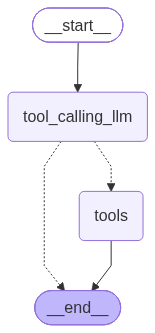

In [ ]:
### Importing LangGraph Components
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

### Defining the Tool Calling Node
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

### Creating the StateGraph
builder=StateGraph(State)

### Adding the Node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

### Adding the Edges
builder.add_edge(START, "tool_calling_llm")

# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges("tool_calling_llm", tools_condition)

builder.add_edge("tools", END)

### Compiling the Graph
graph=builder.compile()

### Displaying the Graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Running the Chatbot with Arxiv

In [29]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_a8b46dc1-416c-47ce-8724-fa50d67f208e)
 Call ID: fc_a8b46dc1-416c-47ce-8724-fa50d67f208e
  Args:
    query: arXiv 1706.03762
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Attention Is All You Need", "url": "https://arxiv.org/pdf/1706.03762", "content": "∗Equal contribution. Listing order is random. Jakob proposed replacing RNNs with self-attention and started the effort to evaluate this idea. Ashish, with Illia, designed and implemented the first Transformer models and has been crucially involved in every aspect of this work. Noam proposed scaled dot-product attention, multi-head attention and the parameter-free position representation and became the other person involved in nearly every deta

### Running the Chatbot with Wikipedia

In [30]:
messages=graph.invoke({"messages":HumanMessage(content="Give me Robert Downey Jr movies featuring in MCU")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me Robert Downey Jr movies featuring in MCU
================================== Ai Message ==================================

**Robert Downey Jr. (Tony Stark / Iron Man) in the Marvel Cinematic Universe**

| MCU Film | Release Year | Role / Notable Appearance |
|----------|--------------|---------------------------|
| *Iron Man* | 2008 | First appearance as Tony Stark / Iron Man |
| *The Avengers* | 2012 | Central member of the Avengers team |
| *Iron Man 2* | 2010 | Continues Stark’s story; introduces Black Widow |
| *Iron Man 3* | 2013 | Post‑Avengers solo adventure |
| *Avengers: Age of Ultron* | 2015 | Key player in the fight against Ultron |
| *Captain America: Civil War* | 2016 | Leads the “Iron Man” side of the superhero conflict |
| *Spider‑Man: Homecoming* | 2017 | Mentor/“friend” to Peter Parker (cameo & supporting role) |
| *Avengers: Infinity War* | 2018 | Part of the battle against Thano

### Running the Chatbot with Tavily Search

In [33]:
messages=graph.invoke({"messages":HumanMessage(content="Who is Dev Goyal from SwapSo")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Who is Dev Goyal from SwapSo
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_402b6d3d-e5f5-4aa4-b7f8-43d59827a3e5)
 Call ID: fc_402b6d3d-e5f5-4aa4-b7f8-43d59827a3e5
  Args:
    query: Dev Goyal SwapSo
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Dev Goyal | Portfolio", "url": "https://devgoyal.netlify.app", "content": "## About me\n\nHello! I'm Dev Goyal, a Pre-final Year Computer Science Engineering (Artificial Intelligence and Machine Learning) student at Noida Institute of Engineering and Technology, Greater Noida. I am primarily interested in Web Development, Python Development, Artificial Intelligence, and Machine Learning.\n\nI bring a diverse range of experiences in technical development, leadership, and community engagement. As Program Dire